Checking token

In [ ]:
import requests

# URL API OneBox
url = "https://ramosu.1b.app/api/v2/token/get/"

# Дані для авторизації
payload = {
    "login": "o.ivaskevych@netpeak.net",
    "restapipassword": "1cbe21f6ba091d90968e40302e30363034333630302031373339353339303135"
}

# Відправляємо POST-запит
response = requests.post(url, json=payload)

# Обробляємо відповідь
if response.status_code == 200:
    token_data = response.json()
    access_token = token_data.get("access_token")
    print("Отриманий токен:", access_token)
else:
    print("Помилка:", response.status_code, response.text)



Отриманий токен: None


In [ ]:
print(response.json())

{'status': 1, 'dataArray': {'token': '827a0ea9597c503acfa7dc3e8f37d0e0'}}


Extraction of data and transforming to dataset for cheking data

In [ ]:
import requests
import json
import pandas as pd

# Base API URL
url_hook = "https://ramosu.1b.app"
AUTH_URL = f"{url_hook}/api/v2/token/get/"

# Authentication Data
payload = {
    "login": "o.ivaskevych@netpeak.net",
    "restapipassword": "1cbe21f6ba091d90968e40302e30363034333630302031373339353339303135"
}

def get_1box_token():
    """Retrieve API access token."""
    response = requests.post(AUTH_URL, json=payload)
    if response.status_code == 200:
        return response.json().get("dataArray", {}).get("token")
    return None

def fetch_orders(token, start_date, end_date):
    """Fetch all orders from 1Box API with pagination."""
    url = f"{url_hook}/api/v2/order/get/"
    headers = {
        "accept": "application/json",
        "token": token,
        "Content-Type": "application/json",
    }

    orders = []
    last_id = 0  # Start pagination

    while True:
        payload = {
            "fields": ["id", "namefull", "name", "namelast", "namemiddle", "typesex", "source", "clientname",  "clientemail", "description", "clientid", "sum", "bonus", "bonushistory",
                       "discountsum", "currency",  "discount", "customfields", "paymentstatus", "discountsumall" "cdate", "dateto", "dateplan", "deliverinote", "status", "workflowid",
                       "currencyname"],
            "limit": 50,
            "filter": {
                "cdatefrom": start_date,
                "cdateto": end_date,
                "lastid": last_id  # Fetch next batch
            }
        }

        response = requests.post(url, headers=headers, json=payload)
        response.raise_for_status()
        data = response.json()

        batch = data.get("dataArray", [])
        if not batch:
            break  # Stop if no more orders

        orders.extend(batch)
        last_id = batch[-1]["id"]  # Get last fetched order ID

    print(f"✅ Total orders retrieved: {len(orders)}")
    return orders

def normalize_orders(orders):
    """Transform raw orders into a structured Pandas DataFrame."""
    if not orders:
        return pd.DataFrame()

    # Normalize main order data
    df_orders = pd.json_normalize(orders)

    # Extract nested fields only if they exist
    df_products = pd.json_normalize(
        [o for o in orders if "products" in o],
        record_path="products",
        meta=["id"],
        errors="ignore",
        record_prefix="product_"
    ) if any("products" in o for o in orders) else pd.DataFrame()

    df_users = pd.json_normalize(
        [o for o in orders if "users" in o],
        record_path="users",
        meta=["id"],
        errors="ignore",
        record_prefix="user_"
    ) if any("users" in o for o in orders) else pd.DataFrame()

    # Merge everything into one DataFrame
    df_final = df_orders.copy()
    if not df_products.empty:
        df_final = df_final.merge(df_products, on="id", how="left")
    if not df_users.empty:
        df_final = df_final.merge(df_users, on="id", how="left")

    # Fill missing values
    df_final.fillna("", inplace=True)

    return df_final

# Execute workflow
access_token = get_1box_token()

if access_token:
    start_date = "2025-01-01"
    end_date = "2025-01-02"
    orders = fetch_orders(access_token, start_date, end_date)

    df_orders = normalize_orders(orders)

    # Display the DataFrame
    print(df_orders.head())


✅ Total orders retrieved: 239
       id customfields.aivkabnetunovoposhti.key  \
0  281554                  aivkabnetunovoposhti   
1  281555                                         
2  281556                  aivkabnetunovoposhti   
3  281557                  aivkabnetunovoposhti   
4  281558                  aivkabnetunovoposhti   

  customfields.aivkabnetunovoposhti.name  \
0                ID кабінету нової пошти   
1                                          
2                ID кабінету нової пошти   
3                ID кабінету нової пошти   
4                ID кабінету нової пошти   

  customfields.aivkabnetunovoposhti.value  \
0                                      33   
1                                           
2                                      30   
3                                      39   
4                                      50   

  customfields.alfamyadlyavdpravkisms.key  \
0                  alfamyadlyavdpravkisms   
1                                    

In [ ]:
print("📊 Column Data Types:")
print(df_orders.dtypes)

📊 Column Data Types:
id                                             object
name                                           object
dateto                                         object
dateplan                                       object
sum                                            object
                                                ...  
customfields.Statusyuridichnoosobi.name        object
customfields.Statusyuridichnoosobi.value       object
customfields.CHekamotovarktvtrachenih.key      object
customfields.CHekamotovarktvtrachenih.name     object
customfields.CHekamotovarktvtrachenih.value    object
Length: 402, dtype: object


In [ ]:
import requests
import json
import pandas as pd

# Base API URL
url_hook = "https://ramosu.1b.app"
AUTH_URL = f"{url_hook}/api/v2/token/get/"

def get_1box_token(api_login, api_password):
    """Retrieve API access token dynamically."""
    payload = {
    "login": "o.ivaskevych@netpeak.net",
    "restapipassword": "1cbe21f6ba091d90968e40302e30363034333630302031373339353339303135"
}
    response = requests.post(AUTH_URL, json=payload)
    if response.status_code == 200:
        return response.json().get("dataArray", {}).get("token")
    return None

def fetch_orders(token, start_date, end_date):
    """Fetch orders from API with pagination."""
    url = f"{url_hook}/api/v2/order/get/"
    headers = {"accept": "application/json", "token": token, "Content-Type": "application/json"}
    orders = []
    last_id = 0  # Pagination start

    while True:
        payload = {
            "fields": ["customfields", "id"],
            "limit": 50,
            "filter": {"cdatefrom": start_date, "cdateto": end_date, "lastid": last_id}
        }

        response = requests.post(url, headers=headers, json=payload)
        response.raise_for_status()
        data = response.json()

        batch = data.get("dataArray", [])
        if not batch:
            break  # Stop if no more orders

        orders.extend(batch)
        last_id = batch[-1]["id"]  # Update last fetched order ID

    print(f"✅ Total orders retrieved: {len(orders)}")
    return orders

import pandas as pd

def extract_relevant_fields(orders):
    """Extract only 'id' and 'customfields.alfamyadlyavdpravkisms.value'"""
    extracted_data = []

    for order in orders:
        order_id = order.get("id")
        customfields = order.get("customfields", [])

        # Ensure customfields is a list
        if isinstance(customfields, dict):
            customfields = [customfields]  # Convert single dict to list
        elif not isinstance(customfields, list):
            customfields = []  # Default to empty list if unexpected type

        # Extract only the desired custom field value
        client_idga = next(
            (cf["value"] for cf in customfields if isinstance(cf, dict) and cf.get("key") == "client_idga"), ""
        )

        extracted_data.append({"id": order_id, "client_idga": client_idga})

    return pd.DataFrame(extracted_data)

# Example usage
access_token = get_1box_token("your_login", "your_password")
if access_token:
    start_date = "2025-01-01"
    end_date = "2025-01-02"
    orders = fetch_orders(access_token, start_date, end_date)

    df_filtered = extract_relevant_fields(orders)

    # Display the DataFrame
    print(df_filtered.head())


✅ Total orders retrieved: 239
       id client_idga
0  281554            
1  281555            
2  281556            
3  281557            
4  281558            


Extract data and load to BigQuery

In [ ]:
import requests
import json
import pandas as pd
from google.cloud import bigquery
from google.oauth2 import service_account

# Base API URL
url_hook = "https://ramosu.1b.app"
AUTH_URL = f"{url_hook}/api/v2/token/get/"

# Authentication Data
payload = {
    "login": "o.ivaskevych@netpeak.net",
    "restapipassword": "1cbe21f6ba091d90968e40302e30363034333630302031373339353339303135"
}

#BigQuery authentification

credentials_path ='/content/red-welder-443815-e2-2ba594cf960c.json'
project_id = "red-welder-443815-e2"
dataset_id = "OneBox_extracted_by_Netpeak"
table_id = "OneBox_one_time_export"

def get_1box_token():
    """Retrieve API access token."""
    response = requests.post(AUTH_URL, json=payload)
    if response.status_code == 200:
        return response.json().get("dataArray", {}).get("token")
    return None

def fetch_orders(token, start_date, end_date):
    """Fetch all orders from 1Box API with pagination."""
    url = f"{url_hook}/api/v2/order/get/"
    headers = {
        "accept": "application/json",
        "token": token,
        "Content-Type": "application/json",
    }

    orders = []
    last_id = 0  # Start pagination

    while True:
        payload = {
            "fields": ["cdate", "sum", "clientid", "paymentstatus",  "status", "customfields"],
            "limit": 50,
            "filter": {
                "cdatefrom": start_date,
                "cdateto": end_date,
                "lastid": last_id  # Fetch next batch
            }
        }

        response = requests.post(url, headers=headers, json=payload)
        response.raise_for_status()
        data = response.json()

        batch = data.get("dataArray", [])
        if not batch:
            break  # Stop if no more orders

        orders.extend(batch)
        last_id = batch[-1]["id"]  # Get last fetched order ID

    print(f"✅ Total orders retrieved: {len(orders)}")
    return orders

def normalize_orders(orders):
    """Transform raw orders into a structured Pandas DataFrame."""
    if not orders:
        return pd.DataFrame()

    # Normalize main order data
    df_orders = pd.json_normalize(orders)

    # Replace invalid column names (dots) with underscores
    df_orders.columns = [col.replace('.', '_') for col in df_orders.columns]

    # Extract nested fields only if they exist
    df_products = pd.json_normalize(
        [o for o in orders if "products" in o],
        record_path="products",
        meta=["id"],
        errors="ignore",
        record_prefix="product_"
    ) if any("products" in o for o in orders) else pd.DataFrame()

    df_users = pd.json_normalize(
        [o for o in orders if "users" in o],
        record_path="users",
        meta=["id"],
        errors="ignore",
        record_prefix="user_"
    ) if any("users" in o for o in orders) else pd.DataFrame()

    # Rename columns in nested DataFrames
    if not df_products.empty:
        df_products.columns = [col.replace('.', '_') for col in df_products.columns]
    if not df_users.empty:
        df_users.columns = [col.replace('.', '_') for col in df_users.columns]

    # Merge everything into one DataFrame
    df_final = df_orders.copy()
    if not df_products.empty:
        df_final = df_final.merge(df_products, on="id", how="left")
    if not df_users.empty:
        df_final = df_final.merge(df_users, on="id", how="left")

    # Fill missing values
    df_final.fillna("", inplace=True)

    return df_final

def upload_to_bigquery(df, project_id, dataset_id, table_id, credentials_path):
    """Upload DataFrame to Google BigQuery using a service account JSON key file."""
    from google.cloud import bigquery
    from google.oauth2 import service_account

    # Load credentials from a file (instead of json.loads)
    credentials = service_account.Credentials.from_service_account_file(credentials_path)
    client = bigquery.Client(credentials=credentials, project=project_id)

    # Ensure all columns with mixed types are converted to strings
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].astype(str)

    table_ref = f"{project_id}.{dataset_id}.{table_id}"

    try:
        job = client.load_table_from_dataframe(df, table_ref, job_config=bigquery.LoadJobConfig(write_disposition="WRITE_APPEND"))
        job.result()  # Wait for completion
        print(f"✅ Successfully uploaded {len(df)} rows to {table_ref}.")
    except Exception as e:
        print(f"❌ Error uploading to BigQuery: {e}")

# Execute workflow
access_token = get_1box_token()

if access_token:
    start_date = "2025-01-01"
    end_date = "2025-03-12"
    orders = fetch_orders(access_token, start_date, end_date)

    df_orders = normalize_orders(orders)

    if not df_orders.empty:
        # Google BigQuery Details
        PROJECT_ID = project_id
        DATASET_ID = dataset_id
        TABLE_ID = table_id
        CREDENTIALS_PATH = credentials_path

        # Upload DataFrame to BigQuery
        upload_to_bigquery(df_orders, PROJECT_ID, DATASET_ID, TABLE_ID, CREDENTIALS_PATH)
    else:
        print("⚠️ No data to upload.")


✅ Total orders retrieved: 35417
✅ Successfully uploaded 35417 rows to red-welder-443815-e2.OneBox_extracted_by_Netpeak.OneBox_one_time_export.


In [ ]:
import requests
import json
import pandas as pd
import logging
import asyncio
from datetime import datetime
from datetime import timedelta
from google.cloud import bigquery
from google.oauth2 import service_account

credentials_path ='/content/red-welder-443815-e2-2ba594cf960c.json'
project_id = "red-welder-443815-e2"
dataset_id = "OneBox_extracted_by_Netpeak"
table_id = "OneBox_one_time_export"

schema = [
    bigquery.SchemaField("date", "TIMESTAMP", mode="NULLABLE"),
    bigquery.SchemaField("revenue", "FLOAT", mode="NULLABLE"),
    bigquery.SchemaField("onebox_client_id", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("status_payment", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("status", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("company", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("campaign", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("source", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("user_pseudo_id", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("session_id", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("transaction_id", "STRING", mode="NULLABLE")
]

def get_1box_token():
    """Retrieve API access token."""
    response = requests.post(AUTH_URL, json=payload)
    if response.status_code == 200:
        return response.json().get("dataArray", {}).get("token")
    return None

def fetch_orders(token, start_date, end_date):
    """Fetch all orders from 1Box API with pagination."""
    url = f"{url_hook}/api/v2/order/get/"
    headers = {
        "accept": "application/json",
        "token": token,
        "Content-Type": "application/json",
    }

    orders = []
    last_id = 0  # Start pagination

    while True:
        payload = {
            "fields": ["id", "cdate", "sum", "clientid", "paymentstatus",  "status", "customfields"],
            "limit": 50,
            "filter": {
                "cdatefrom": start_date,
                "cdateto": end_date,
                "lastid": last_id  # Fetch next batch
            }
        }

        response = requests.post(url, headers=headers, json=payload)
        response.raise_for_status()
        data = response.json()

        batch = data.get("dataArray", [])
        if not batch:
            break  # Stop if no more orders

        orders.extend(batch)
        last_id = batch[-1]["id"]  # Get last fetched order ID

    print(f"✅ Total orders retrieved: {len(orders)}")
    return orders

def normalize_orders(orders):
    """Transform raw orders into a structured Pandas DataFrame."""
    if not orders:
        return pd.DataFrame()

    # Normalize main order data
    df_orders = pd.json_normalize(orders)

    # Replace invalid column names (dots) with underscores
    df_orders.columns = [col.replace('.', '_') for col in df_orders.columns]

    # Extract nested fields only if they exist
    df_products = pd.json_normalize(
        [o for o in orders if "products" in o],
        record_path="products",
        meta=["id"],
        errors="ignore",
        record_prefix="product_"
    ) if any("products" in o for o in orders) else pd.DataFrame()

    df_users = pd.json_normalize(
        [o for o in orders if "users" in o],
        record_path="users",
        meta=["id"],
        errors="ignore",
        record_prefix="user_"
    ) if any("users" in o for o in orders) else pd.DataFrame()

    # Rename columns in nested DataFrames
    if not df_products.empty:
        df_products.columns = [col.replace('.', '_') for col in df_products.columns]
    if not df_users.empty:
        df_users.columns = [col.replace('.', '_') for col in df_users.columns]

    # Merge everything into one DataFrame
    df_final = df_orders.copy()
    if not df_products.empty:
        df_final = df_final.merge(df_products, on="id", how="left")
    if not df_users.empty:
        df_final = df_final.merge(df_users, on="id", how="left")

    # Fill missing values
    df_final.fillna("", inplace=True)
    # df_final = df_final[["cdate",
    #                       "sum,",
    #                       "clientid",
    #                       "paymentstatus",
    #                       "status_name",
    #                       "customfields_alfamyadlyavdpravkisms_value",
    #                       "customfields_utm_campaingcopy_value",
    #                       "customfields_utm_sourcecopy_value",
    #                       "customfields_client_idga_value",
    #                       "customfields_session_idga_value",
    #                       "customfields_transaction_idga_value"
    #                     ]]
    return df_final

# def get_three_days_ago():
#     """
#     Returns the date three days ago in format 'YYYY-MM-DD'
#     """
#     three_days_ago = datetime.now() - timedelta(days=3)
#     return three_days_ago.strftime('%Y-%m-%d')

# def exist_dataset_table(client, table_id, dataset_id, project_id, clustering_fields=None):
#     '''
#     Validates and creates a table in Google BigQuery
#     :client: Google BigQuery Client
#     :table_id: table identifier
#     :dataset_id: dataset identifier
#     :project_id: project ID
#     :schema: Google BigQuery table schema
#     :clustering_fields: table clustering
#     '''

#     try:
#         dataset_ref = "{}.{}".format(project_id, dataset_id)
#         client.get_dataset(dataset_ref)

#     except NotFound:
#         dataset_ref = "{}.{}".format(project_id, dataset_id)
#         dataset = bigquery.Dataset(dataset_ref)
#         dataset.location = "us-central1"
#         dataset = client.create_dataset(dataset)

#         logger.info(f'Dataset was created {client.project}.{dataset.dataset_id}')

#     try:
#         table_ref = "{}.{}.{}".format(project_id, dataset_id, table_id)
#         client.get_table(table_ref)

#     except NotFound:

#         table_ref = "{}.{}.{}".format(project_id, dataset_id, table_id)

#         table = bigquery.Table(table_ref, schema=schema)

#         table.time_partitioning = bigquery.TimePartitioning(
#             type_=bigquery.TimePartitioningType.DAY,
#             field="date"
#         )

#         if clustering_fields is not None:
#             table.clustering_fields = clustering_fields

#         table = client.create_table(table)
#         logger.info(f'Table was created {table_ref}')

#     return 'ok'

# def delete_existing_data(project_id, dataset_id, table_id, start_date, end_date):
#     """Delete existing records in BigQuery for the given date range."""
#     client = bigquery.Client()
#     query = f"""
#         DELETE FROM `{project_id}.{dataset_id}.{table_id}`
#         WHERE DATE(cdate) BETWEEN '{start_date}' AND '{end_date}'
#     """
#     try:
#         query_job = client.query(query)
#         query_job.result()  # Wait for completion
#         print(f"✅ Deleted existing data for {start_date} to {end_date}")
#     except Exception as e:
#         print(f"❌ Error deleting existing data: {e}")

# def upload_to_bigquery(df, project_id, dataset_id, table_id, credentials_path):
#     """Upload DataFrame to Google BigQuery using a service account JSON key file."""
#     from google.cloud import bigquery
#     from google.oauth2 import service_account

#     # Load credentials from a file (instead of json.loads)
#     credentials = service_account.Credentials.from_service_account_file(credentials_path)
#     client = bigquery.Client(credentials=credentials, project=project_id)

#     # Ensure all columns with mixed types are converted to strings
#     for col in df.columns:
#         if df[col].dtype == object:
#             df[col] = df[col].astype(str)

#     table_ref = f"{project_id}.{dataset_id}.{table_id}"

#     try:
#         job = client.load_table_from_dataframe(df, table_ref, job_config=bigquery.LoadJobConfig(write_disposition="WRITE_APPEND"))
#         job.result()  # Wait for completion
#         print(f"✅ Successfully uploaded {len(df)} rows to {table_ref}.")
#     except Exception as e:
#         print(f"❌ Error uploading to BigQuery: {e}")

# Execute workflow
access_token = get_1box_token()

if access_token:
    start_date = "2025-01-01"
    end_date = "2025-01-02"
    orders = fetch_orders(access_token, start_date, end_date)

    df_orders = normalize_orders(orders)

    if not df_orders.empty:
        # Google BigQuery Details
        PROJECT_ID = project_id
        DATASET_ID = dataset_id
        TABLE_ID = table_id
        CREDENTIALS_PATH = credentials_path

    #     # Upload DataFrame to BigQuery
    #     upload_to_bigquery(df_orders, PROJECT_ID, DATASET_ID, TABLE_ID, CREDENTIALS_PATH)
    # else:
        print("⚠️ No data to upload.")


✅ Total orders retrieved: 239
⚠️ No data to upload.


In [ ]:
import requests
import json
import pandas as pd
from google.cloud import bigquery

# Google BigQuery setup
credentials_path = '/content/red-welder-443815-e2-2ba594cf960c.json'
project_id = "red-welder-443815-e2"
dataset_id = "OneBox_extracted_by_Netpeak"
table_id = "OneBox_test"

schema = [
    bigquery.SchemaField("date", "TIMESTAMP", mode="NULLABLE"),
    bigquery.SchemaField("revenue", "FLOAT", mode="NULLABLE"),
    bigquery.SchemaField("onebox_client_id", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("status_payment", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("status", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("company", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("campaign", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("source", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("user_pseudo_id", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("session_id", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("transaction_id", "STRING", mode="NULLABLE")
]

# 1Box API Setup (DEFINE THESE VARIABLES)
# Base API URL
url_hook = "https://ramosu.1b.app"
AUTH_URL = f"{url_hook}/api/v2/token/get/"

# Authentication Data
payload = {
    "login": "o.ivaskevych@netpeak.net",
    "restapipassword": "1cbe21f6ba091d90968e40302e30363034333630302031373339353339303135"
}

def get_1box_token():
    """Retrieve API access token."""
    response = requests.post(AUTH_URL, json=payload)
    if response.status_code == 200:
        return response.json().get("dataArray", {}).get("token")
    return None

def fetch_orders(token, start_date, end_date):
    """Fetch all orders from 1Box API with pagination."""
    url = f"{url_hook}/api/v2/order/get/"
    headers = {
        "accept": "application/json",
        "token": token,
        "Content-Type": "application/json",
    }

    orders = []
    last_id = 0  # Start pagination

    while True:
        payload = {
            "fields": ["id", "cdate", "sum", "clientid", "paymentstatus", "status", "customfields"],
            "limit": 50,
            "filter": {
                "cdatefrom": start_date,
                "cdateto": end_date,
                "lastid": last_id  # Fetch next batch
            }
        }

        response = requests.post(url, headers=headers, json=payload)
        response.raise_for_status()
        data = response.json()

        batch = data.get("dataArray", [])
        if not batch:
            break  # Stop if no more orders

        orders.extend(batch)
        last_id = batch[-1]["id"]  # Get last fetched order ID

    print(f"✅ Total orders retrieved: {len(orders)}")
    return orders

def normalize_orders(orders):
    """Normalize and filter raw orders into a structured Pandas DataFrame with correct data types."""
    if not orders:
        return pd.DataFrame()

    # Convert API response to DataFrame
    df_orders = pd.json_normalize(orders)

    # Replace invalid column names (dots) with underscores
    df_orders.columns = [col.replace('.', '_') for col in df_orders.columns]

    # **Filter necessary columns**
    required_columns = {
        "cdate": "date",
        "sum": "revenue",
        "clientid": "onebox_client_id",
        "paymentstatus": "status_payment",
        "status_name": "status",
        "customfields_alfamyadlyavdpravkisms_value": "company",
        "customfields_utm_campaingcopy_value": "campaign",
        "customfields_utm_sourcecopy_value": "source",
        "customfields_client_idga_value": "user_pseudo_id",
        "customfields_session_idga_value": "session_id",
        "customfields_transaction_idga_value": "transaction_id"
    }

    # Keep only the selected columns (if they exist in df)
    df_filtered = df_orders[[col for col in required_columns.keys() if col in df_orders.columns]]

    # Rename columns
    df_filtered = df_filtered.rename(columns=required_columns)

    # ✅ Convert data types explicitly
    if "date" in df_filtered.columns:
        df_filtered["date"] = pd.to_datetime(df_filtered["date"])  # Convert to Timestamp

    if "revenue" in df_filtered.columns:
        df_filtered["revenue"] = pd.to_numeric(df_filtered["revenue"], errors="coerce")  # Convert to Float

    # Ensure all other columns are strings (BigQuery expects them as STRING)
    for col in ["onebox_client_id", "status_payment", "status", "company", "campaign", "source",
                "user_pseudo_id", "session_id", "transaction_id"]:
        if col in df_filtered.columns:
            df_filtered[col] = df_filtered[col].astype(str)

    return df_filtered

def check_and_create_table(client, dataset_id, table_id, schema):
    """
    Checks if the table exists in BigQuery. If not, creates the table.
    """
    dataset_ref = client.dataset(dataset_id)
    table_ref = dataset_ref.table(table_id)

    try:
        client.get_table(table_ref)  # Try to get the table
        print(f"❌ Table {table_id} already exists.")
    except Exception as e:
        # If table does not exist, create it
        table = bigquery.Table(table_ref, schema=schema)
        client.create_table(table)
        print(f"✅ Table {table_id} is created.")

def upload_to_bigquery(df, project_id, dataset_id, table_id, credentials_path):
    """Upload DataFrame to Google BigQuery using a service account JSON key file."""
    from google.cloud import bigquery
    from google.oauth2 import service_account

    # Load credentials from a file (instead of json.loads)
    credentials = service_account.Credentials.from_service_account_file(credentials_path)
    client = bigquery.Client(credentials=credentials, project=project_id)

    # Ensure all columns with mixed types are converted to strings
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].astype(str)

    table_ref = f"{project_id}.{dataset_id}.{table_id}"

    # Check and create table if necessary
    check_and_create_table(client, dataset_id, table_id, schema)

    try:
        job = client.load_table_from_dataframe(df, table_ref, job_config=bigquery.LoadJobConfig(write_disposition="WRITE_APPEND"))
        job.result()  # Wait for completion
        print(f"✅ Successfully uploaded {len(df)} rows to {table_ref}.")
    except Exception as e:
        print(f"❌ Error uploading to BigQuery: {e}")

# Execute workflow
access_token = get_1box_token()

if access_token:
    start_date = "2025-03-12"
    end_date = "2025-03-30"
    orders = fetch_orders(access_token, start_date, end_date)

    df_orders = normalize_orders(orders)

    if not df_orders.empty:
        # Google BigQuery Details
        PROJECT_ID = project_id
        DATASET_ID = dataset_id
        TABLE_ID = table_id
        CREDENTIALS_PATH = credentials_path

        # Upload DataFrame to BigQuery
        upload_to_bigquery(df_orders, PROJECT_ID, DATASET_ID, TABLE_ID, CREDENTIALS_PATH)
    else:
        print("⚠️ No data to upload.")


✅ Total orders retrieved: 7756
✅ Table OneBox_test is created.
✅ Successfully uploaded 7756 rows to red-welder-443815-e2.OneBox_extracted_by_Netpeak.OneBox_test.


In [ ]:
import requests
import json
import pandas as pd
from datetime import datetime, timedelta, date
from google.cloud import bigquery
from google.oauth2 import service_account

# Google BigQuery setup
credentials_path = '/content/red-welder-443815-e2-2ba594cf960c.json'
project_id = "red-welder-443815-e2"
dataset_id = "OneBox_extracted_by_Netpeak"
table_id = "OneBox_test"

schema = [
    bigquery.SchemaField("date", "TIMESTAMP", mode="NULLABLE"),
    bigquery.SchemaField("revenue", "FLOAT", mode="NULLABLE"),
    bigquery.SchemaField("onebox_client_id", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("status_payment", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("status", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("company", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("campaign", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("source", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("user_pseudo_id", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("session_id", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("transaction_id", "STRING", mode="NULLABLE")
]

# 1Box API Setup
url_hook = "https://ramosu.1b.app"
AUTH_URL = f"{url_hook}/api/v2/token/get/"

# Authentication Data
payload = {
    "login": "o.ivaskevych@netpeak.net",
    "restapipassword": "1cbe21f6ba091d90968e40302e30363034333630302031373339353339303135"
}

def get_max_date_from_bigquery(client, project_id, dataset_id, table_id):
    """Fetch the maximum date from BigQuery table and return max(date) + 1 day."""
    query = f"""
        SELECT MAX(DATE(date)) AS max_date
        FROM `{project_id}.{dataset_id}.{table_id}`
    """
    try:
        query_job = client.query(query)
        result = query_job.result()
        for row in result:
            if row.max_date:
                return (row.max_date + timedelta(days=1))  # Keep as `date`
    except Exception as e:
        print(f"⚠️ Error fetching max date: {e}")
        return None  # Return None if an error occurs

# Set Default Start & End Dates
credentials = service_account.Credentials.from_service_account_file(credentials_path)
client = bigquery.Client(credentials=credentials, project=project_id)

today = datetime.today().date()  # Ensure today is a date
three_days_ago = (datetime.now() - timedelta(days=3)).date()  # Convert to date

# Get max date from BigQuery
max_date_from_bq = get_max_date_from_bigquery(client, project_id, dataset_id, table_id) if table_id else None

# Determine start_date: prioritize BigQuery max_date, else use three_days_ago
start_date = max_date_from_bq if max_date_from_bq else three_days_ago

# Ensure we delete and fetch data from the correct period
start_date = min(start_date, three_days_ago)

# Set end date as today
end_date = today

# Check Date Difference
if start_date > end_date:
    print("⚠️ No uploading is necessary.")
    exit()

print(f"✅ Fetching data from {start_date} to {end_date}")

def get_1box_token():
    """Retrieve API access token."""
    response = requests.post(AUTH_URL, json=payload)
    if response.status_code == 200:
        return response.json().get("dataArray", {}).get("token")
    return None

def fetch_orders(token, start_date, end_date):
    """Fetch all orders from 1Box API with pagination."""
    url = f"{url_hook}/api/v2/order/get/"
    headers = {
        "accept": "application/json",
        "token": token,
        "Content-Type": "application/json",
    }

    orders = []
    last_id = 0  # Start pagination

    # ✅ Ensure `start_date` and `end_date` are strings
    start_date = start_date.strftime("%Y-%m-%d") if isinstance(start_date, (datetime, date)) else start_date
    end_date = end_date.strftime("%Y-%m-%d") if isinstance(end_date, (datetime, date)) else end_date

    while True:
        payload = {
            "fields": ["id", "cdate", "sum", "clientid", "paymentstatus", "status", "customfields"],
            "limit": 50,
            "filter": {
                "cdatefrom": start_date,
                "cdateto": end_date,
                "lastid": last_id
            }
        }

        response = requests.post(url, headers=headers, json=payload)
        response.raise_for_status()
        data = response.json()

        batch = data.get("dataArray", [])
        if not batch:
            break  # Stop if no more orders

        orders.extend(batch)
        last_id = batch[-1]["id"]  # Get last fetched order ID

    print(f"✅ Total orders retrieved: {len(orders)}")
    return orders

def normalize_orders(orders):
    """Normalize and filter raw orders into a structured Pandas DataFrame with correct data types."""
    if not orders:
        return pd.DataFrame()

    # Convert API response to DataFrame
    df_orders = pd.json_normalize(orders)

    # Replace invalid column names (dots) with underscores
    df_orders.columns = [col.replace('.', '_') for col in df_orders.columns]

    # **Filter necessary columns**
    required_columns = {
        "cdate": "date",
        "sum": "revenue",
        "clientid": "onebox_client_id",
        "paymentstatus": "status_payment",
        "status_name": "status",
        "customfields_alfamyadlyavdpravkisms_value": "company",
        "customfields_utm_campaingcopy_value": "campaign",
        "customfields_utm_sourcecopy_value": "source",
        "customfields_client_idga_value": "user_pseudo_id",
        "customfields_session_idga_value": "session_id",
        "customfields_transaction_idga_value": "transaction_id"
    }

    # Keep only the selected columns (if they exist in df)
    df_filtered = df_orders[[col for col in required_columns.keys() if col in df_orders.columns]]

    # Rename columns
    df_filtered = df_filtered.rename(columns=required_columns)

    # ✅ Convert data types explicitly
    if "date" in df_filtered.columns:
        df_filtered["date"] = pd.to_datetime(df_filtered["date"])  # Convert to Timestamp

    if "revenue" in df_filtered.columns:
        df_filtered["revenue"] = pd.to_numeric(df_filtered["revenue"], errors="coerce")  # Convert to Float

    # Ensure all other columns are strings (BigQuery expects them as STRING)
    for col in ["onebox_client_id", "status_payment", "status", "company", "campaign", "source",
                "user_pseudo_id", "session_id", "transaction_id"]:
        if col in df_filtered.columns:
            df_filtered[col] = df_filtered[col].astype(str)

    return df_filtered

def delete_old_data(client, dataset_id, table_id, start_date):
    """Deletes data from BigQuery table for the last 3 days or based on manually set start_date."""

    query = f"""
        DELETE FROM `{project_id}.{dataset_id}.{table_id}`
        WHERE DATE(date) >= '{start_date}'
    """
    try:
        query_job = client.query(query)
        query_job.result()  # Wait for completion
        print(f"✅ Deleted old data from {table_id} for date >= {start_date}")
    except Exception as e:
        print(f"❌ Error deleting old data: {e}")

def check_and_create_table(client, dataset_id, table_id, schema):
    """Checks if the table exists in BigQuery. If not, creates the table."""
    dataset_ref = client.dataset(dataset_id)
    table_ref = dataset_ref.table(table_id)

    try:
        client.get_table(table_ref)
        print(f"⚠️ Table {table_id} already exists.")
    except Exception:
        table = bigquery.Table(table_ref, schema=schema)
        client.create_table(table)
        print(f"✅ Table {table_id} created.")

def upload_to_bigquery(df, project_id, dataset_id, table_id, credentials_path):
    """Upload DataFrame to Google BigQuery using a service account JSON key file."""
    credentials = service_account.Credentials.from_service_account_file(credentials_path)
    client = bigquery.Client(credentials=credentials, project=project_id)

    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].astype(str)

    table_ref = f"{project_id}.{dataset_id}.{table_id}"
    check_and_create_table(client, dataset_id, table_id, schema)

    try:
        job = client.load_table_from_dataframe(df, table_ref, job_config=bigquery.LoadJobConfig(write_disposition="WRITE_APPEND"))
        job.result()
        print(f"✅ Successfully uploaded {len(df)} rows to {table_ref}.")
    except Exception as e:
        print(f"❌ Error uploading to BigQuery: {e}")

# Execute workflow
delete_old_data(client, dataset_id, table_id, start_date)

access_token = get_1box_token()

if access_token:
    orders = fetch_orders(access_token, start_date, end_date)
    df_orders = normalize_orders(orders)

    if not df_orders.empty:
        upload_to_bigquery(df_orders, project_id, dataset_id, table_id, credentials_path)
    else:
        print("⚠️ No data to upload.")


✅ Fetching data from 2025-03-29 to 2025-04-01
✅ Deleted old data from OneBox_test for date >= 2025-03-29
✅ Total orders retrieved: 1163
⚠️ Table OneBox_test already exists.
✅ Successfully uploaded 1163 rows to red-welder-443815-e2.OneBox_extracted_by_Netpeak.OneBox_test.


In [ ]:
import requests
import json
import base64
import pandas as pd
import google.auth
import logging
from datetime import datetime, timedelta
from google.cloud import bigquery
from google.oauth2 import service_account

# Configure logger
logger = logging.getLogger()
logger.setLevel(logging.INFO)

# Set up BigQuery client with default authentication
credentials, project_id = google.auth.default()
client = bigquery.Client(credentials=credentials, project=project_id)

# 1Box API Setup
url_hook = "https://ramosu.1b.app"
AUTH_URL = f"{url_hook}/api/v2/token/get/"

# Authentication Data
payload = {
    "login": "o.ivaskevych@netpeak.net",
    "restapipassword": "1cbe21f6ba091d90968e40302e30363034333630302031373339353339303135"
}

# Define BigQuery Schema
schema = [
    bigquery.SchemaField("id", "INTEGER"),
    bigquery.SchemaField("cdate", "TIMESTAMP"),
    bigquery.SchemaField("sum", "FLOAT"),
    bigquery.SchemaField("clientid", "STRING"),
    bigquery.SchemaField("paymentstatus", "STRING"),
    bigquery.SchemaField("status", "STRING"),
    bigquery.SchemaField("customfields", "STRING"),
]

def get_max_date_from_bigquery(client, project_id, dataset_id, table_id):
    """Fetch the maximum date from BigQuery table and return max(date) + 1 day."""
    logger.info(f"Fetching max date from {dataset_id}.{table_id}...")

    query = f"""
        SELECT MAX(DATE(date)) AS max_date
        FROM `{project_id}.{dataset_id}.{table_id}`
    """
    try:
        query_job = client.query(query)
        result = query_job.result()
        for row in result:
            if row.max_date:
                max_date = row.max_date + timedelta(days=1)
                logger.info(f"Max date found: {row.max_date}, setting start_date to {max_date}")
                return max_date
    except Exception as e:
        logger.error(f"Error fetching max date: {e}")
        return None

def get_1box_token():
    """Retrieve API access token."""
    logger.info("Requesting 1Box API token...")

    response = requests.post(AUTH_URL, json=payload)
    if response.status_code == 200:
        return response.json().get("dataArray", {}).get("token")
    else:
        logger.error(f"Failed to get API token. Status: {response.status_code}, Response: {response.text}")
        return None

def fetch_orders(token, start_date, end_date):
    """Fetch orders from 1Box API with pagination."""
    logger.info(f"Fetching orders from {start_date} to {end_date}...")

    url = f"{url_hook}/api/v2/order/get/"
    headers = {
        "accept": "application/json",
        "token": token,
        "Content-Type": "application/json",
    }

    orders = []
    last_id = 0

    start_date = start_date.strftime("%Y-%m-%d")
    end_date = end_date.strftime("%Y-%m-%d")

    while True:
        payload = {
            "fields": ["id", "cdate", "sum", "clientid", "paymentstatus", "status", "customfields"],
            "limit": 50,
            "filter": {
                "cdatefrom": start_date,
                "cdateto": end_date,
                "lastid": last_id
            }
        }

        response = requests.post(url, headers=headers, json=payload)
        response.raise_for_status()
        data = response.json()

        batch = data.get("dataArray", [])
        if not batch:
            break

        orders.extend(batch)
        last_id = batch[-1].get("id", last_id)  # Handle missing 'id' field

    logger.info(f"Total orders retrieved: {len(orders)}")
    return orders

def normalize_orders(orders):
    """Normalize and filter raw orders into a structured Pandas DataFrame with correct data types."""
    if not orders:
        return pd.DataFrame()

    # Convert API response to DataFrame
    df_orders = pd.json_normalize(orders)

    # Replace invalid column names (dots) with underscores
    df_orders.columns = [col.replace('.', '_') for col in df_orders.columns]

    # **Filter necessary columns**
    required_columns = {
        "cdate": "date",
        "sum": "revenue",
        "clientid": "onebox_client_id",
        "paymentstatus": "status_payment",
        "status_name": "status",
        "customfields_alfamyadlyavdpravkisms_value": "company",
        "customfields_utm_campaingcopy_value": "campaign",
        "customfields_utm_sourcecopy_value": "source",
        "customfields_client_idga_value": "user_pseudo_id",
        "customfields_session_idga_value": "session_id",
        "customfields_transaction_idga_value": "transaction_id"
    }

    # Keep only the selected columns (if they exist in df)
    df = df_orders[[col for col in required_columns.keys() if col in df_orders.columns]]

    # Rename columns
    df = df.rename(columns=required_columns)

    # ✅ Convert data types explicitly
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])  # Convert to Timestamp

    if "revenue" in df.columns:
        df["revenue"] = pd.to_numeric(df["revenue"], errors="coerce")  # Convert to Float

    # Ensure all other columns are strings (BigQuery expects them as STRING)
    for col in ["onebox_client_id", "status_payment", "status", "company", "campaign", "source",
                "user_pseudo_id", "session_id", "transaction_id"]:
        if col in df.columns:
            df[col] = df[col].astype(str)

    return df

def delete_old_data(client, project_id, dataset_id, table_id, start_date):
    """Delete old data from BigQuery table."""
    logger.info(f"Deleting old data from {dataset_id}.{table_id} where date >= {start_date}")

    query = f"""
        DELETE FROM `{project_id}.{dataset_id}.{table_id}`
        WHERE DATE(cdate) >= '{start_date}'
    """
    try:
        client.query(query).result()
        logger.info("Old data deleted successfully.")
    except Exception as e:
        logger.error(f"Error deleting old data: {e}")

def exist_dataset_table_grp(client, table_id, dataset_id, project_id, schema, clustering_fields=None):
    """Get the existing dataset and the table in the current project.
        If they don't exist: create the dataset and the table in the current project.

    Args:
        client: BigQuery Client.
        table_id (str): The table ID of BigQuery.
        dataset_id (str): The dataset ID of BigQuery.
        project_id (str): The project name of Google Cloud account.
        schema: The schema of the target BigQuery table.
        clustering_fields: Fields for clustering.

    Returns:
        str
    """

    try:
        dataset_ref = "{}.{}".format(project_id, dataset_id)
        client.get_dataset(dataset_ref)  # Make an API request.

    except NotFound:
        dataset_ref = "{}.{}".format(project_id, dataset_id)
        dataset = bigquery.Dataset(dataset_ref)
        dataset.location = "US"
        dataset = client.create_dataset(dataset)  # Make an API request.
        logger.info("Created dataset {}.{}".format(client.project, dataset.dataset_id))

    try:
        table_ref = "{}.{}.{}".format(project_id, dataset_id, table_id)
        client.get_table(table_ref)  # Make an API request.

    except NotFound:

        table_ref = "{}.{}.{}".format(project_id, dataset_id, table_id)

        table = bigquery.Table(table_ref, schema=schema)



        if clustering_fields is not None:
            table.clustering_fields = clustering_fields

        table = client.create_table(table)  # Make an API request.
        logger.info("Created table {}.{}.{}".format(table.project, table.dataset_id, table.table_id))

    return "ok"

def upload_to_bigquery(df, project_id, dataset_id, table_id):
    """Upload DataFrame to BigQuery: Create table if empty, Append otherwise."""

    table_ref = "{}.{}.{}".format(project_id, dataset_id, table_id)

    job_config = bigquery.LoadJobConfig()
    job_config.schema = schema

    # Check if the table exists
    try:
        client.get_table(table_ref)  # Try to get the table
        job_config.write_disposition = "WRITE_APPEND"  # Append if table exists
        logger.info(f"📌 Table {table_ref} exists. Appending data.")
    except Exception:
        logger.info(f"⚠️ Table {table_ref} does not exist. Skipping upload as table creation is handled elsewhere.")
        return  # Exit function without attempting to upload

    try:
        logger.info(f"🚀 Uploading {len(df)} rows to {table_ref} in BigQuery...")
        job = client.load_table_from_dataframe(dataframe=df, destination=table_ref, job_config=job_config)
        job.result()  # Wait for the job to complete
        logger.info(f"✅ Successfully uploaded {len(df)} rows to {table_ref}.")
    except Exception as e:
        logger.error(f"❌ Error uploading to BigQuery: {e}")

async def main(event, context):
    """Main function for Cloud Run execution."""
    logger.info("Starting Cloud Run function...")

    bigquery_client = bigquery.Client()

    # Decode Pub/Sub message
    pubsub_message = base64.b64decode(event['data']).decode('utf-8')
    logger.info(f"Received Pub/Sub message: {pubsub_message}")

    if pubsub_message == 'onebox':
        dataset_id = event['attributes']['dataset_id']
        table_id = event['attributes']['table_id']
        logger.info(f"Target dataset: {dataset_id}, Target table: {table_id}")

        # Determine start & end date
        if 'start_date' in event['attributes'] and 'end_date' in event['attributes']:
            start_date = datetime.strptime(event['attributes']['start_date'], "%Y-%m-%d").date()
            end_date = datetime.strptime(event['attributes']['end_date'], "%Y-%m-%d").date()
        else:
            start_date = get_max_date_from_bigquery(bigquery_client, project_id, dataset_id, table_id)
            end_date = datetime.today().date()

            if not start_date:
                start_date = (datetime.today() - timedelta(days=3)).date()

            start_date = min(start_date, (datetime.today() - timedelta(days=3)).date())

        logger.info(f"Final date range: {start_date} to {end_date}")

        #Defining client
        client = bigquery.Client(project=project_id)

        # Delete old data before fetching new data
        delete_old_data(bigquery_client, project_id, dataset_id, table_id, start_date)

        # Fetch & upload new data
        access_token = get_1box_token()
        if access_token:
            orders = fetch_orders(token, start_date, end_date)
            df = normalize_orders(orders)

            if not df.empty:
                exist_dataset_table_grp(client, table_id, dataset_id, project_id, schema, clustering_fields=None)
                upload_to_bigquery(df, project_id, dataset_id, table_id)
            else:
                logger.warning("No data to upload.")
        else:
            logger.warning("Unknown Pub/Sub message received. Skipping execution.")

def entry_point(event, context):
    """Cloud Run entry point."""
    import asyncio
    asyncio.run(main(event, context))


In [1]:
# main

# functions-framework==3.*
# google-cloud-bigquery
# google-cloud-logging
# google-auth
# google-auth-oauthlib
# google-auth-httplib2
# pandas
# pyarrow
# requests
# datetime
# flask
# asyncio




import functions_framework
import requests
import pandas as pd
import logging
from datetime import datetime, timedelta
from flask import Request
from google.api_core.exceptions import NotFound
from google.cloud import bigquery
import asyncio

# Configure logger
logger = logging.getLogger()
logger.setLevel(logging.INFO)

# Define BigQuery Schema
schema = [
    bigquery.SchemaField("date", "TIMESTAMP"),
    bigquery.SchemaField("revenue", "FLOAT"),
    bigquery.SchemaField("onebox_client_id", "STRING"),
    bigquery.SchemaField("status_payment", "STRING"),
    bigquery.SchemaField("status", "STRING"),
    bigquery.SchemaField("company", "STRING"),
    bigquery.SchemaField("campaign", "STRING"),
    bigquery.SchemaField("source", "STRING"),
    bigquery.SchemaField("user_pseudo_id", "STRING"),
    bigquery.SchemaField("session_id", "STRING"),
    bigquery.SchemaField("transaction_id", "STRING"),
]




def get_max_date_from_bigquery(client, project_id, dataset_id, table_id):
    """Fetch the maximum date from BigQuery table and return max(date) + 1 day."""
    logger.info(f"Fetching max date from {dataset_id}.{table_id}...")

    query = f"""
        SELECT MAX(DATE(date)) AS max_date
        FROM `{project_id}.{dataset_id}.{table_id}`
    """
    try:
        query_job = client.query(query)
        result = query_job.result()
        for row in result:
            if row.max_date:
                max_date = row.max_date + timedelta(days=1)
                logger.info(f"Max date found: {row.max_date}, setting start_date to {max_date}")
                return max_date
    except Exception as e:
        logger.error(f"Error fetching max date: {e}")
        return None


def get_1box_token(url_hook, login, restapipassword):
    """Retrieve API access token."""
    logger.info("Requesting 1Box API token...")
    # 1Box API Setup
    AUTH_URL = f"{url_hook}/api/v2/token/get/"

    # Authentication Data
    payload = {
        "login": f"{login}",
        "restapipassword": f"{restapipassword}"
    }
    response = requests.post(AUTH_URL, json=payload)
    if response.status_code == 200:
        return response.json().get("dataArray", {}).get("token")
    else:
        logger.error(f"Failed to get API token. Status: {response.status_code}, Response: {response.text}")
        return None


def fetch_orders(token, url_hook, start_date, end_date):
    """Fetch orders from 1Box API with pagination."""
    logger.info(f"Fetching orders from {start_date} to {end_date}...")

    url = f"{url_hook}/api/v2/order/get/"
    headers = {
        "accept": "application/json",
        "token": token,
        "Content-Type": "application/json",
    }

    orders = []
    last_id = 0

    start_date = start_date.strftime("%Y-%m-%d")
    end_date = end_date.strftime("%Y-%m-%d")

    while True:
        payload = {
            "fields": ["id", "cdate", "sum", "clientid", "paymentstatus", "status", "customfields"],
            "limit": 50,
            "filter": {
                "cdatefrom": start_date,
                "cdateto": end_date,
                "lastid": last_id
            }
        }

        response = requests.post(url, headers=headers, json=payload)
        logger.info(f"Request payload: {payload}")
        logger.info(f"Response status: {response.status_code}")
        logger.info(f"Response text: {response.text}")
        response.raise_for_status()
        data = response.json()

        batch = data.get("dataArray", [])
        if not batch:
            break

        orders.extend(batch)
        last_id = batch[-1].get("id", last_id)  # Handle missing 'id' field

    logger.info(f"Total orders retrieved: {len(orders)}")
    return orders


def normalize_orders(orders):
    """Normalize and filter raw orders into a structured Pandas DataFrame with correct data types."""
    if not orders:
        return pd.DataFrame()

    # Convert API response to DataFrame
    df_orders = pd.json_normalize(orders)

    # Replace invalid column names (dots) with underscores
    df_orders.columns = [col.replace('.', '_') for col in df_orders.columns]

    # **Filter necessary columns**
    required_columns = {
        "cdate": "date",
        "sum": "revenue",
        "clientid": "onebox_client_id",
        "paymentstatus": "status_payment",
        "status_name": "status",
        "customfields_alfamyadlyavdpravkisms_value": "company",
        "customfields_utm_campaingcopy_value": "campaign",
        "customfields_utm_sourcecopy_value": "source",
        "customfields_client_idga_value": "user_pseudo_id",
        "customfields_session_idga_value": "session_id",
        "customfields_transaction_idga_value": "transaction_id"
    }

    # Keep only the selected columns (if they exist in df)
    df = df_orders[[col for col in required_columns.keys() if col in df_orders.columns]]

    # Rename columns
    df = df.rename(columns=required_columns)

    # ✅ Convert data types explicitly
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])  # Convert to Timestamp

    if "revenue" in df.columns:
        df["revenue"] = pd.to_numeric(df["revenue"], errors="coerce")  # Convert to Float

    # Ensure all other columns are strings (BigQuery expects them as STRING)
    for col in ["onebox_client_id", "status_payment", "status", "company", "campaign", "source",
                "user_pseudo_id", "session_id", "transaction_id"]:
        if col in df.columns:
            df[col] = df[col].astype(str)

    for expected_col in required_columns.values():
        if expected_col not in df.columns:
            df[expected_col] = None

    df = df[[field.name for field in schema]]

    return df



def table_exists(client, project_id, dataset_id, table_id):
    """Check if a BigQuery table exists."""
    try:
        table_ref = f"{project_id}.{dataset_id}.{table_id}"
        client.get_table(table_ref)
        return True
    except NotFound:
        logger.warning(f"⚠️ Table {table_ref} not found.")
        return False


def delete_old_data(client, project_id, dataset_id, table_id, start_date):
    """Delete old data from BigQuery table if it exists."""
    table_ref = f"{project_id}.{dataset_id}.{table_id}"

    if not table_exists(client, project_id, dataset_id, table_id):
        logger.info(f"🛑 Table {table_ref} does not exist. Skipping deletion.")
        return

    query = f"""
        DELETE FROM `{table_ref}`
        WHERE DATE(date) >= '{start_date}'
    """
    try:
        client.query(query).result()
        logger.info(f"✅ Old data deleted successfully from {table_ref}.")
    except Exception as e:
        logger.error(f"❌ Error deleting old data from {table_ref}: {e}")



def exist_dataset_table_grp(client, table_id, dataset_id, project_id, schema, clustering_fields=None):
    """Get the existing dataset and the table in the current project.
        If they don't exist: create the dataset and the table in the current project.

    Args:
        client: BigQuery Client.
        table_id (str): The table ID of BigQuery.
        dataset_id (str): The dataset ID of BigQuery.
        project_id (str): The project name of Google Cloud account.
        schema: The schema of the target BigQuery table.
        clustering_fields: Fields for clustering.

    Returns:
        str
    """

    try:
        dataset_ref = "{}.{}".format(project_id, dataset_id)
        client.get_dataset(dataset_ref)  # Make an API request.

    except NotFound:
        dataset_ref = "{}.{}".format(project_id, dataset_id)
        dataset = bigquery.Dataset(dataset_ref)
        dataset.location = "US"
        dataset = client.create_dataset(dataset)  # Make an API request.
        logger.info("Created dataset {}.{}".format(client.project, dataset.dataset_id))

    try:
        table_ref = "{}.{}.{}".format(project_id, dataset_id, table_id)
        client.get_table(table_ref)  # Make an API request.

    except NotFound:

        table_ref = "{}.{}.{}".format(project_id, dataset_id, table_id)

        table = bigquery.Table(table_ref, schema=schema)

        if clustering_fields is not None:
            table.clustering_fields = clustering_fields

        table = client.create_table(table)  # Make an API request.
        logger.info("Created table {}.{}.{}".format(table.project, table.dataset_id, table.table_id))

    return "ok"


def upload_to_bigquery(df, client, project_id, dataset_id, table_id):
    """Upload DataFrame to BigQuery: Create table if empty, Append otherwise."""

    table_ref = "{}.{}.{}".format(project_id, dataset_id, table_id)

    job_config = bigquery.LoadJobConfig()
    job_config.schema = schema

    # Check if the table exists
    try:
        client.get_table(table_ref)  # Try to get the table
        job_config.write_disposition = "WRITE_APPEND"  # Append if table exists
        logger.info(f"📌 Table {table_ref} exists. Appending data.")
    except Exception:
        logger.info(f"⚠️ Table {table_ref} does not exist. Skipping upload as table creation is handled elsewhere.")
        return  # Exit function without attempting to upload

    try:
        logger.info(f"🚀 Uploading {len(df)} rows to {table_ref} in BigQuery...")
        job = client.load_table_from_dataframe(dataframe=df, destination=table_ref, job_config=job_config)
        job.result()  # Wait for the job to complete
        logger.info(f"✅ Successfully uploaded {len(df)} rows to {table_ref}.")
    except Exception as e:
        logger.error(f"❌ Error uploading to BigQuery: {e}")


async def main(request: Request):
    """Main function for Cloud Run execution."""
    logger.info("Starting Cloud Run function...")

    if not request.is_json:
        return "Invalid request format", 400

    body = request.get_json(silent=True) or {}
    url_hook = body.get("url_hook", "")
    login = body.get("login", "")
    restapipassword = body.get("restapipassword", "")
    project_id = body.get("project_id", "")
    dataset_id = body.get("dataset_id", "")
    table_id = body.get("table_id", "")

    bigquery_client = bigquery.Client()

    logger.info(f"Target dataset: {dataset_id}, Target table: {table_id}")

    # Determine start & end date
    if 'start_date' in body and 'end_date' in body:
        start_date = datetime.strptime(body.get('start_date',''), "%Y-%m-%d").date()
        end_date = datetime.strptime(body.get('end_date',''), "%Y-%m-%d").date()
    else:
        start_date = get_max_date_from_bigquery(bigquery_client, project_id, dataset_id, table_id)
        end_date = datetime.today().date()

        if not start_date:
            start_date = (datetime.today() - timedelta(days=3)).date()

        start_date = min(start_date, (datetime.today() - timedelta(days=3)).date())

    logger.info(f"Final date range: {start_date} to {end_date}")
    exist_dataset_table_grp(bigquery_client, table_id, dataset_id, project_id, schema)

    # Delete old data before fetching new data
    delete_old_data(bigquery_client, project_id, dataset_id, table_id, start_date)

    # Fetch & upload new data
    access_token = get_1box_token(url_hook, login, restapipassword)
    if access_token:
        orders = fetch_orders(access_token, url_hook, start_date, end_date)
        df = normalize_orders(orders)

        if not df.empty:
            exist_dataset_table_grp(bigquery_client, table_id, dataset_id, project_id, schema,
                                    clustering_fields=None)
            upload_to_bigquery(df, bigquery_client, project_id, dataset_id, table_id)
        else:
            logger.warning("No data to upload.")
    else:
        logger.warning("Unknown Pub/Sub message received. Skipping execution.")
    return 'ok'


@functions_framework.http
def entry_point(request: Request):
    loop = asyncio.new_event_loop()
    asyncio.set_event_loop(loop)
    try:
        return loop.run_until_complete(main(request))
    except Exception as e:
        logger.error(f"Error in entry_point: {e}")
        return "Internal Server Error", 500
    finally:
        loop.close()



ModuleNotFoundError: No module named 'functions_framework'

In [ ]:
# body:
#  {
#     "url_hook": "https://ramosu.1b.app",
#     "login": "o.ivaskevych@netpeak.net",
#     "restapipassword": "1cbe21f6ba091d90968e40302e30363034333630302031373339353339303135",
#     "project_id": "red-welder-443815-e2",
#     "dataset_id": "OneBox_extracted_by_Netpeak",
#     "table_id": "OneBox_test",
#     "start_date":"2025-03-28",
#     "end_date":"2025-04-04"
# }

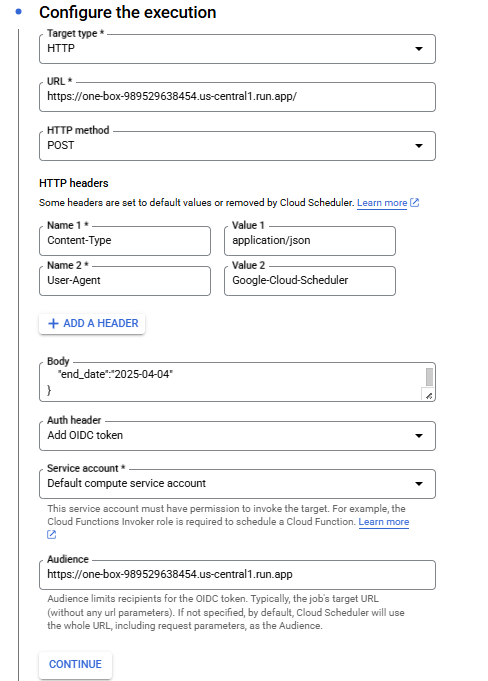